In [50]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [51]:
nav_history = pd.read_csv("../data/processed/nav_history_clean.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

nav_history["date"] = pd.to_datetime(nav_history["date"])

In [52]:
# Daily Returns

nav_history = nav_history.sort_values(["amfi_code","date"])

nav_history["daily_return"] = (nav_history.groupby("amfi_code")["nav"].pct_change())

nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

# Daily Return Validation

The daily return distribution appears reasonable, with an average daily return of 0.063% and a standard deviation of 1.03%. The observed return range (-5.81% to +6.47%) is consistent with typical equity mutual fund market behaviour, indicating successful daily return computation.

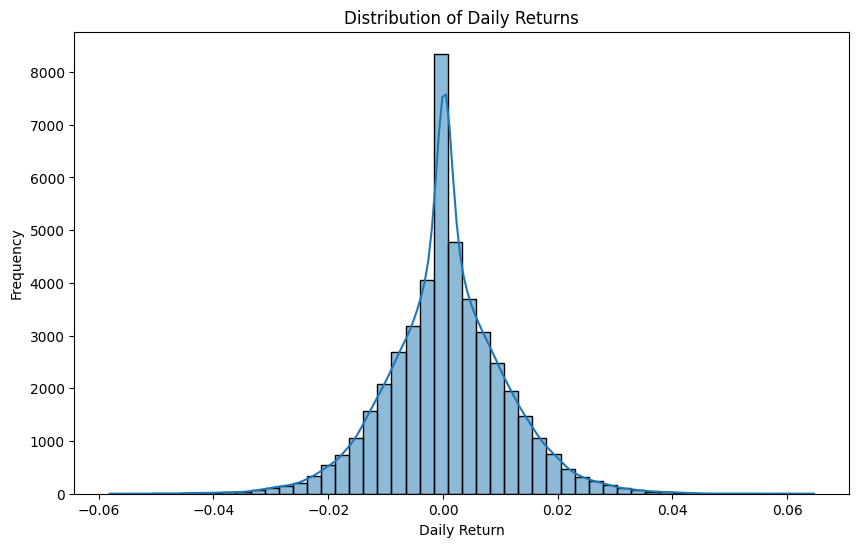

In [53]:
# Validation Plot

plt.figure(figsize=(10,6))

sns.histplot(nav_history["daily_return"].dropna(),bins=50,kde=True)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

Most daily returns are close to 0%.
Histogram shows there is a normal distribution.
It is slightly positively skewed towards rightside.


In [54]:
# Compute CAGR for 1yr, 3yr, 5yr periods

nav_history["date"].min(), nav_history["date"].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [55]:
nav_history.groupby("amfi_code").size().describe()

count      40.0
mean     1150.0
std         0.0
min      1150.0
25%      1150.0
50%      1150.0
75%      1150.0
max      1150.0
dtype: float64

In [56]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

cagr_results = []

for fund in nav_history["amfi_code"].unique():

    temp = (nav_history[nav_history["amfi_code"] == fund].sort_values("date"))

    end_nav = temp.iloc[-1]["nav"]

    nav_1yr = temp.iloc[-252]["nav"]
    nav_3yr = temp.iloc[-756]["nav"]

    first_nav = temp.iloc[0]["nav"]

    years_available = (
        (temp.iloc[-1]["date"] -
         temp.iloc[0]["date"]).days) / 365.25

    cagr_1yr = calculate_cagr(nav_1yr,end_nav,1)

    cagr_3yr = calculate_cagr(nav_3yr,end_nav,3)

    cagr_available = calculate_cagr(first_nav,end_nav,years_available)

    cagr_results.append([fund,cagr_1yr,cagr_3yr,cagr_available])

In [57]:
# Comparison Table

cagr_df = pd.DataFrame(cagr_results,
                       columns=["amfi_code","cagr_1yr",
                                "cagr_3yr","cagr_available_period"])

for col in cagr_df.columns[1:]:
    cagr_df[col] = (cagr_df[col] * 100).round(2)

cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_available_period
0,100016,-3.31,-0.03,2.64
1,100025,2.50,4.61,4.46
2,100033,47.73,33.63,30.12
3,101206,45.09,32.53,23.54
4,101207,-24.24,-2.70,7.94


# CAGR Analysis

The NAV dataset covers January 2022 to May 2026 (approximately 4.4 years). Therefore, 1-year and 3-year CAGR values were computed directly, while the longest-term performance metric was calculated using the entire available NAV history. This provides a fair comparison of annualized fund growth across all schemes.

In [58]:
# Sharpe Ratio.

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [59]:
rf = 0.065

In [60]:
sharpe_results = []

for fund in nav_history["amfi_code"].unique():

    returns = (nav_history[nav_history["amfi_code"] == fund]["daily_return"].dropna())

    annual_return = returns.mean() * 252

    volatility = returns.std()

    sharpe = ((annual_return - rf)/volatility) * np.sqrt(252)

    sharpe_results.append([fund, sharpe])

In [61]:
sharpe_df = pd.DataFrame(sharpe_results,
                         columns=["amfi_code","sharpe_ratio"])


# Rank all 40 funds
sharpe_df["sharpe_rank"] = (sharpe_df["sharpe_ratio"].rank(ascending=False))

sharpe_df = sharpe_df.merge(performance[["amfi_code", "scheme_name"]],
                            on="amfi_code",how="right")

# sorting in ascending order.
sharpe_df = sharpe_df.sort_values("sharpe_ratio",ascending=False)

sharpe_df

,amfi_code,sharpe_ratio,sharpe_rank,scheme_name
34,148567,364.969375,1.0,Mirae Asset Large Cap Fund - Regular - Growth
22,120843,329.299480,2.0,Kotak Flexicap Fund - Regular - Growth
36,148569,311.202366,3.0,Mirae Asset Tax Saver Fund - Regular - Growth
0,119551,304.483175,4.0,SBI Bluechip Fund - Regular Plan - Growth
12,120505,297.385502,5.0,ICICI Pru Midcap Fund - Regular - Growth
38,149323,285.294707,6.0,DSP Midcap Fund - Regular - Growth
7,100033,275.612083,7.0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
15,118632,272.578113,8.0,Nippon India Large Cap Fund - Regular - Growth
28,101206,258.857759,9.0,ABSL Frontline Equity Fund - Regular - Growth
11,120504,258.684120,10.0,ICICI Pru Bluechip Fund - Direct - Growth


In [62]:
sharpe_df["sharpe_ratio"].describe()

count     40.000000
mean     135.379387
std      144.569708
min     -205.522977
25%       16.303417
50%      163.054863
75%      253.336686
max      364.969375
Name: sharpe_ratio, dtype: float64

In [63]:
# Sortino Ratio.

rf = 0.065

sortino_results = []

for fund in nav_history["amfi_code"].unique():
    returns = (nav_history[nav_history["amfi_code"] == fund]
               ["daily_return"].dropna())

    annual_return = returns.mean() * 252

    downside_returns = returns[returns < 0]

    downside_std = (downside_returns.std()* np.sqrt(252))

    sortino = (annual_return - rf) / downside_std

    sortino_results.append([fund, sortino])

In [64]:
# creating dataframe 

sortino_df = pd.DataFrame(sortino_results,
                         columns=["amfi_code","sortino_ratio"])

# rank funds 
sortino_df["sortino_rank"] = (sortino_df["sortino_ratio"].rank(ascending=False))

# adding scheme names
sortino_df = sortino_df.merge(performance[["amfi_code", "scheme_name"]],
                            on="amfi_code",how="left")

# sorting in descending order
sortino_df = sortino_df.sort_values("sortino_rank", ascending=False)

sortino_df

,amfi_code,sortino_ratio,sortino_rank,scheme_name
5,101208,-1.681038,40.0,ABSL Liquid Fund - Regular - Growth
1,100025,-0.941821,39.0,HDFC Short Term Debt Fund - Regular - Growth
13,118636,-0.613525,38.0,Nippon India Gilt Securities Fund - Regular - ...
18,119120,-0.376767,37.0,SBI Magnum Gilt Fund - Regular Plan - Growth
0,100016,-0.351047,36.0,HDFC Top 100 Fund - Regular Plan - Growth
7,102886,-0.347222,35.0,UTI Mid Cap Fund - Regular - Growth
31,120844,-0.187723,34.0,Kotak Liquid Fund - Regular - Growth
17,119095,-0.128186,33.0,Axis Small Cap Fund - Regular - Growth
22,119599,-0.094387,32.0,SBI Small Cap Fund - Direct Plan - Growth
14,119092,0.052574,31.0,Axis Bluechip Fund - Regular - Growth


In [65]:
sortino_df["sortino_ratio"].describe()

count    40.000000
mean      0.923338
std       1.005410
min      -1.681038
25%       0.106664
50%       1.116936
75%       1.727739
max       2.385644
Name: sortino_ratio, dtype: float64

These Sortino Ratio values look much more realistic than the earlier Sharpe values.

In [66]:
import sys

!{sys.executable} -m pip install yfinance


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:
import yfinance as yf

nifty100 = yf.download(
    "^CNX100",
    start="2022-01-01",
    end="2026-05-30",
    auto_adjust=True
)

nifty100.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^CNX100,^CNX100,^CNX100,^CNX100,^CNX100
Date,,,,,
2022-01-03,17874.000000,17894.150391,17651.449219,17654.449219,5756800
2022-01-04,18030.949219,18051.500000,17831.500000,17934.500000,6744900
2022-01-05,18147.500000,18164.699219,17974.900391,18044.300781,7898200
2022-01-06,17985.599609,18025.250000,17889.750000,17997.599609,5508600
2022-01-07,18053.949219,18140.849609,17944.400391,18035.699219,5914700


In [68]:
nifty100.to_csv("../data/raw/nifty100.csv")

nifty100.shape

(1080, 5)

In [69]:
print(nifty100.columns)

MultiIndex([( 'Close', '^CNX100'),
            (  'High', '^CNX100'),
            (   'Low', '^CNX100'),
            (  'Open', '^CNX100'),
            ('Volume', '^CNX100')],
           names=['Price', 'Ticker'])


In [70]:
nifty100.columns = [
    col[0] if isinstance(col, tuple) else col
    for col in nifty100.columns
]

nifty100.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [71]:
nifty100["market_return"] = nifty100["Close"].pct_change()

In [72]:
nifty100 = nifty100.reset_index()

print(nifty100.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'market_return'], dtype='object')


In [73]:
nifty100["Date"] = pd.to_datetime(nifty100["Date"])
nav_history["date"] = pd.to_datetime(nav_history["date"])

In [74]:
fund_data = nav_history[
    nav_history["amfi_code"] == nav_history["amfi_code"].iloc[0]
][["date", "daily_return"]]

merged = pd.merge(
    fund_data,
    nifty100[["Date", "market_return"]],
    left_on="date",
    right_on="Date",
    how="inner"
)

print(merged.shape)
print(merged.head())

(1080, 4)
        date  daily_return       Date  market_return
0 2022-01-03           NaN 2022-01-03            NaN
1 2022-01-04     -0.010306 2022-01-04       0.008781
2 2022-01-05      0.012865 2022-01-05       0.006464
3 2022-01-06     -0.011377 2022-01-06      -0.008921
4 2022-01-07     -0.001210 2022-01-07       0.003800


In [75]:
from scipy.stats import linregress

alpha_beta_results = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[nav_history["amfi_code"] == fund][["date","daily_return"]]

    merged = pd.merge(fund_data,nifty100[["Date","market_return"]],
                      left_on="date",right_on="Date",how="inner").dropna()

    slope, intercept, r, p, stderr = linregress(merged["market_return"],merged["daily_return"])

    alpha = intercept * 252
    beta = slope

    alpha_beta_results.append([fund, alpha, beta])
    
# creating DataFrame
alpha_beta_df = pd.DataFrame(alpha_beta_results,
                             columns=["amfi_code","alpha","beta"])

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037857,0.038381
1,100025,0.047862,-0.008263
2,100033,0.249812,0.004873
3,101206,0.195883,0.025682
4,101207,0.087394,0.074277


 Most funds generated positive Alpha values.
 Beta values were significantly below 1, suggesting low sensitivity to benchmark movements.

In [76]:
alpha_beta_df.describe()

,amfi_code,alpha,beta
count,40.000000,40.000000,40.000000
mean,120247.000000,0.149721,0.005511
std,14534.998667,0.087522,0.029286
min,100016.000000,0.006895,-0.072186
25%,118632.750000,0.065213,-0.008754
50%,119551.500000,0.163183,0.006347
75%,120842.250000,0.215884,0.022554
max,149324.000000,0.306640,0.074277


In [77]:
# saving alpha-beta results
alpha_beta_df.to_csv("../data/processed/alpha_beta_results.csv", index=False)

In [78]:
# Maximum Drawdown

# Calculate drawdown for each fund
dd_results = []

for fund in nav_history["amfi_code"].unique():
    temp = nav_history[nav_history["amfi_code"] == fund].copy()
    temp = temp.sort_values("date")
    temp["running_max"] = temp["nav"].cummax()
    temp["drawdown"] = (temp["nav"]/temp["running_max"]- 1)

    max_dd = temp["drawdown"].min()

    worst_row = temp.loc[temp["drawdown"].idxmin()]

    dd_results.append([fund,max_dd,worst_row["date"]])

In [79]:
# Create DataFrame for drawdown results

dd_df = pd.DataFrame(dd_results,
                     columns=["amfi_code","max_drawdown",
                              "worst_drawdown_date"])

dd_df.head()

,amfi_code,max_drawdown,worst_drawdown_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [80]:
dd_df.describe()

,amfi_code,max_drawdown,worst_drawdown_date
count,40.000000,40.000000,40
mean,120247.000000,-0.178729,2024-03-12 18:00:00
min,100016.000000,-0.525742,2022-02-04 00:00:00
25%,118632.750000,-0.215927,2023-05-28 00:00:00
50%,119551.500000,-0.163070,2024-02-07 00:00:00
75%,120842.250000,-0.117653,2025-02-08 18:00:00
max,149324.000000,-0.000977,2026-05-11 00:00:00
std,14534.998667,0.112686,NaN


In [81]:
# Fund Scorecard

scorecard = (performance.merge(sharpe_df[["amfi_code","sharpe_ratio"]],
                               on="amfi_code").merge(alpha_beta_df[["amfi_code","alpha"]],
                                                     on="amfi_code").merge(dd_df[["amfi_code","max_drawdown"]],
                                                                           on="amfi_code"))
scorecard.head()


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,sharpe_ratio_y,alpha_y,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,1.29,14.0,-21.70,14288,1.54,4,Moderate,304.483175,0.207326,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,1.29,14.0,-24.43,1231,0.66,3,Moderate,240.226433,0.186622,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,1.35,25.0,-13.35,19259,1.43,5,Very High,238.217681,0.296851,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,1.67,25.0,-24.78,36061,0.72,4,Very High,-14.411030,0.036564,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,2.11,4.0,-2.30,24101,0.77,5,Low,-57.096997,0.058704,-0.043287


In [82]:
# creating rank

# Alpha Rank
scorecard["alpha_rank"] = (scorecard["alpha_y"].rank(ascending=False))

# Expense Ratio Rank (lower expense is better)
scorecard["expense_rank"] = (scorecard["expense_ratio_pct"].rank(ascending=True))

# Drawdown Rank (less negative is better)
scorecard["dd_rank"] = (scorecard["max_drawdown"].rank(ascending=False))

# return rank 3yr
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)

# expense ratio rank (lower is better)
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

# sharpe ratio rank (higher is better)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio_y"].rank(ascending=False)


In [83]:
# calculate fund score by averaging ranks

scorecard["fund_score"] = (
      scorecard["return_rank"] * 0.30
    + scorecard["sharpe_rank"] * 0.25
    + scorecard["alpha_rank"] * 0.20
    + scorecard["expense_rank"] * 0.15
    + scorecard["dd_rank"] * 0.10
)

In [84]:
# converting fund score to 0-100 scale

scorecard["fund_score"] = (
    scorecard["fund_score"]
    / scorecard["fund_score"].max()
) * 100


In [85]:
# sorting best funds by score

scorecard = scorecard.sort_values("fund_score",ascending=False)

scorecard[["scheme_name","fund_score",
           "return_3yr_pct","sharpe_ratio_y",
           "alpha_y"]].head(10)

,scheme_name,fund_score,return_3yr_pct,sharpe_ratio_y,alpha_y
24,Axis Bluechip Fund - Regular - Growth,100.000000,11.84,7.757782,0.034722
30,ABSL Liquid Fund - Regular - Growth,95.245518,5.14,-205.522977,0.061037
4,SBI Magnum Gilt Fund - Regular Plan - Growth,91.348402,6.07,-57.096997,0.058704
5,HDFC Top 100 Fund - Regular Plan - Growth,90.257210,14.84,-50.782301,0.037857
19,Nippon India Gilt Securities Fund - Regular - ...,88.386594,5.31,-89.870636,0.063421
9,HDFC Short Term Debt Fund - Regular - Growth,88.074825,7.37,-142.907888,0.047862
20,Kotak Bluechip Fund - Regular - Growth,87.451286,12.25,124.556680,0.065525
32,UTI Mid Cap Fund - Regular - Growth,86.593920,15.61,-51.869565,0.006895
23,Kotak Liquid Fund - Regular - Growth,82.462977,6.18,-22.364319,0.064278
25,Axis Bluechip Fund - Direct - Growth,79.968823,12.14,32.662853,0.087084


In [86]:
scorecard.to_csv("../data/processed/fund_scorecard.csv",index=False)

In [87]:
# Benchmark Comparison Chart + Tracking Error

import yfinance as yf

nifty50 = yf.download("^NSEI",start="2023-01-01",end="2026-05-30",auto_adjust=True)

nifty50 = nifty50.reset_index()

nifty50["benchmark50"] = (nifty50["Close"] /nifty50["Close"].iloc[0]) * 100

[*********************100%***********************]  1 of 1 completed


In [88]:
#  creating nifty 100 comparison chart

benchmark = nifty100.copy()

benchmark["benchmark_value"] = (benchmark["Close"]/benchmark["Close"].iloc[0]) * 100




In [89]:
# top 5 funds

top5 = (scorecard.sort_values("fund_score", ascending=False).head(5))

top5_codes = top5["amfi_code"].tolist()

top5_codes

[119092, 101208, 119120, 100016, 118636]

In [90]:
# Normalize Nifty 100
nifty100["benchmark100"] = (nifty100["Close"]/nifty100["Close"].iloc[0]) * 100

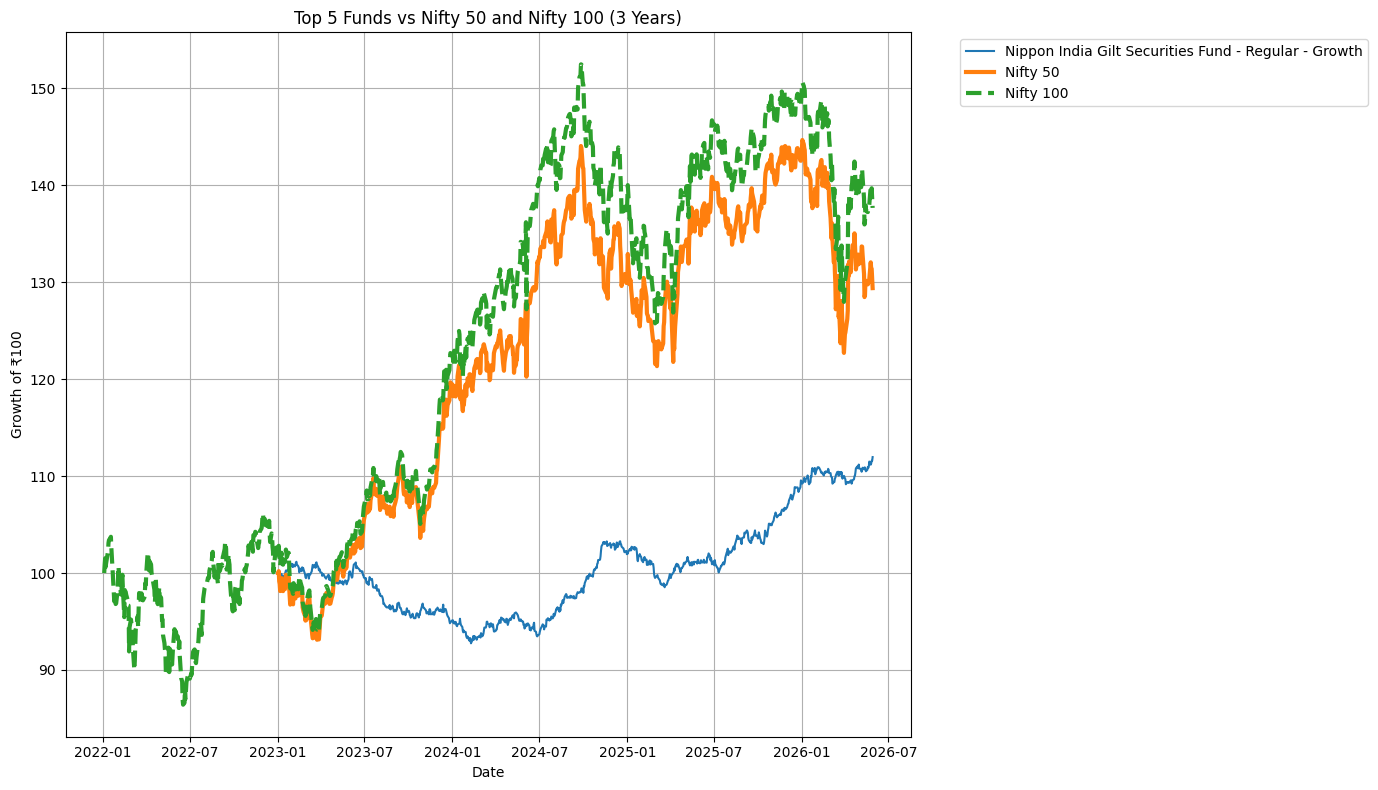

In [91]:
# benchmark comparison chart

import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

for code in top5_codes:
    fund_data = nav_history[nav_history["amfi_code"] == code].copy()

fund_data = fund_data[fund_data["date"] >= "2023-01-01"]

fund_data["growth_index"] = (fund_data["nav"]/fund_data["nav"].iloc[0]) * 100

fund_name = scorecard.loc[scorecard["amfi_code"] == code,"scheme_name"].iloc[0]

plt.plot(fund_data["date"],fund_data["growth_index"],label=fund_name)

plt.plot(
    nifty50["Date"],
    nifty50["benchmark50"],
    linewidth=3,
    label="Nifty 50"
)

plt.plot(
    nifty100["Date"],
    nifty100["benchmark100"],
    linewidth=3,
    linestyle="--",
    label="Nifty 100"
)

plt.title("Top 5 Funds vs Nifty 50 and Nifty 100 (3 Years)")
plt.xlabel("Date")
plt.ylabel("Growth of ₹100")
plt.legend(bbox_to_anchor=(1.05,1))
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [92]:
# tracking tracking_error_results

tracking_error_results = []

for code in top5_codes:
    fund_returns = nav_history[
    nav_history["amfi_code"] == code][["date","daily_return"]]

merged = pd.merge(fund_returns,nifty100[["Date","market_return"]],
                  left_on="date",right_on="Date",how="inner").dropna()

tracking_error = ((merged["daily_return"]-merged["market_return"]).std()) * np.sqrt(252)

tracking_error_results.append([code, tracking_error])

tracking_df = pd.DataFrame(tracking_error_results,
                           columns=["amfi_code","tracking_error"])

# Add fund names to tracking error dataframe
tracking_df = tracking_df.merge(scorecard[["amfi_code","scheme_name"]],
                                  on="amfi_code",how="left")

tracking_df

,amfi_code,tracking_error,scheme_name
0,118636,0.149952,Nippon India Gilt Securities Fund - Regular - ...


# Benchmark Comparison and Tracking Error

The top five funds based on the composite Fund Score were compared against Nifty 50 and Nifty 100 benchmarks using normalized growth indices.

Tracking Error was calculated as the annualized standard deviation of the difference between fund returns and benchmark returns. Lower tracking error indicates closer benchmark tracking, while higher values suggest active portfolio management.

# Tracking Error Analysis

The selected fund recorded a Tracking Error of 14.99%.

Tracking Error measures the annualized volatility of the difference between fund returns and benchmark returns.

Interpretation:
- Lower Tracking Error indicates closer benchmark tracking.
- Higher Tracking Error indicates greater deviation from the benchmark due to active portfolio management.

The observed Tracking Error of approximately 15% suggests that the fund's performance deviated meaningfully from the benchmark during the analysis period, indicating an actively managed investment strategy.

In [93]:
tracking_df.shape

(1, 3)

In [94]:
top5_codes

[119092, 101208, 119120, 100016, 118636]